# Analyse et Modélisation de Risque Médical

## Introduction

Dans ce projet, nous analysons un **dataset médical** contenant diverses informations démographiques, cliniques et comportementales des patients. L'objectif principal est de **prédire la probabilité qu'un patient soit à haut risque (`is_high_risk`)** à partir de ses caractéristiques.

---

## Objectifs

1. **Préparation des données**  
   - Nettoyage des valeurs manquantes  
   - Encodage des variables catégorielles  

2. **Exploration des données**  
   - Analyse des distributions des variables  
   - Étude des corrélations entre variables  

3. **Modélisation prédictive**  
   - Entraînement de plusieurs modèles de classification :  
     - Régression logistique  
     - Arbre de décision  
     - K-Nearest Neighbors (KNN)  
     - XGBoost  

4. **Évaluation des modèles**  
   - Précision, rappel, F1-score  
   - Matrice de confusion  
   - Comparaison des performances pour sélectionner le meilleur modèle  

---

## Méthodologie

- Les données sont d'abord **prétraitées** pour gérer les valeurs manquantes et encoder les variables catégorielles.  
- Ensuite, les jeux de données sont **équilibrés** grâce à ADASYN pour gérer le déséquilibre de la variable cible.  
- Les données sont **divisées en train et test**, puis plusieurs modèles sont entraînés et évalués.  
- Les résultats permettent de **comparer la performance** des modèles et de choisir le modèle le plus performant pour la prédiction du risque médical.


In [5]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#For ignoring warning
import warnings
warnings.filterwarnings("ignore")

In [7]:
df=pd.read_csv('/content/medical_insurance.csv')
df

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0.0,1.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,0.0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0.0,0.0,1.0,1.0,0.0,2.0,1.0,0.0,1.0,0.0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38005,57584,26,Male,West,Urban,52200.0,HS,Single,Unemployed,3,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
38006,39328,36,Female,East,Urban,72300.0,Some College,Divorced,Employed,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
38007,71690,60,Male,West,Urban,69800.0,Bachelors,Married,Retired,3,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0
38008,74447,62,Female,South,Urban,33500.0,Bachelors,Married,Employed,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [8]:
df.shape

(38010, 54)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df=df.drop_duplicates()

In [11]:
df.isnull().sum()

,0
person_id,0
age,0
sex,0
region,0
urban_rural,0
income,0
education,0
marital_status,0
employment_status,0
household_size,0


**Supprimer les lignes avec valeurs manquantes**

In [12]:
df = df.dropna()


In [13]:
df.isnull().sum()

,0
person_id,0
age,0
sex,0
region,0
urban_rural,0
income,0
education,0
marital_status,0
employment_status,0
household_size,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26491 entries, 1 to 38008
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    26491 non-null  int64  
 1   age                          26491 non-null  int64  
 2   sex                          26491 non-null  object 
 3   region                       26491 non-null  object 
 4   urban_rural                  26491 non-null  object 
 5   income                       26491 non-null  float64
 6   education                    26491 non-null  object 
 7   marital_status               26491 non-null  object 
 8   employment_status            26491 non-null  object 
 9   household_size               26491 non-null  int64  
 10  dependents                   26491 non-null  int64  
 11  bmi                          26491 non-null  float64
 12  smoker                       26491 non-null  object 
 13  alcohol_freq         

In [15]:
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,26491.000000,26491.000000,26491.000000,26491.000000,26491.000000,26491.000000,26491.000000,26491.000000,26491.000000,26491.000000,...,26491.000000,26491.000000,26491.000000,26491.000000,26491.000000,26491.000000,26491.000000,26491.000000,26491.000000,26491.000000
mean,50181.687932,47.477445,49874.115737,2.427617,0.894304,26.978736,1.931977,0.092673,0.370692,1.238458,...,0.016458,0.105394,0.129327,0.505002,0.157714,0.502246,0.511796,0.511230,0.367181,0.168548
std,28826.189443,16.053886,46722.087870,1.066635,0.945675,5.012348,1.722362,0.302718,1.365511,1.208949,...,0.127233,0.307067,0.335568,0.749483,0.462610,0.741496,0.756376,0.755336,0.482046,0.374359
min,7.000000,0.000000,1100.000000,1.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25197.000000,37.000000,21200.000000,2.000000,0.000000,23.600000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50154.000000,47.000000,36600.000000,2.000000,1.000000,27.000000,2.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,75138.000000,58.000000,62000.000000,3.000000,1.000000,30.400000,3.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,799000.000000,8.000000,6.000000,45.600000,18.000000,3.000000,14.000000,9.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,6.000000,7.000000,1.000000,1.000000


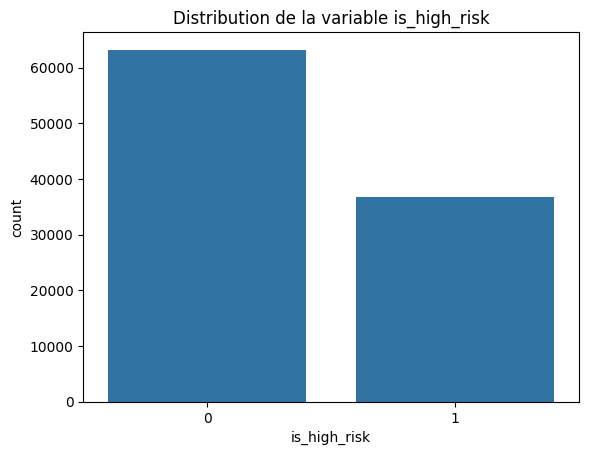

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualiser la répartition de la variable cible 'is_high_risk'
sns.countplot(x='is_high_risk', data=df)
plt.title('Distribution de la variable is_high_risk')
plt.show()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,0,2,1,22700.0,Doctorate,1,1,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,0,2,2,12800.0,No HS,1,0,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,1,2,0,40700.0,HS,1,1,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,1,2,1,15600.0,Some College,1,2,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,1,0,1,89600.0,Doctorate,1,2,2,...,0,1,0,2,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,1,4,2,127200.0,No HS,1,0,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,1,1,1,21600.0,HS,1,0,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,1,4,0,81900.0,HS,0,3,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,0,3,2,43400.0,Doctorate,2,3,3,...,0,0,1,0,0,2,2,1,0,0


Compter le nombre de valeurs uniques pour la colonne 'is_high_risk'

In [22]:

df['is_high_risk'].value_counts()



,count
is_high_risk,
0,63219
1,36781


Fonction pour tracer la répartition

In [23]:
def plot(col, df=df):
    return df.groupby(col)['is_high_risk'].value_counts(normalize=True).unstack().plot(kind='bar', figsize=(8,5))


<Axes: xlabel='sex'>

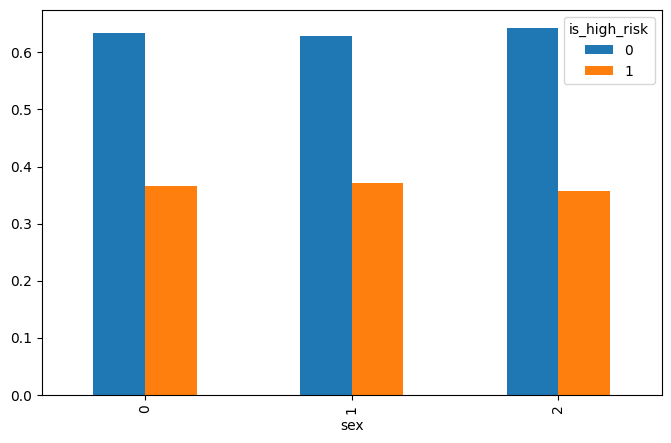

In [24]:
plot('sex')


<Axes: xlabel='age_bin'>

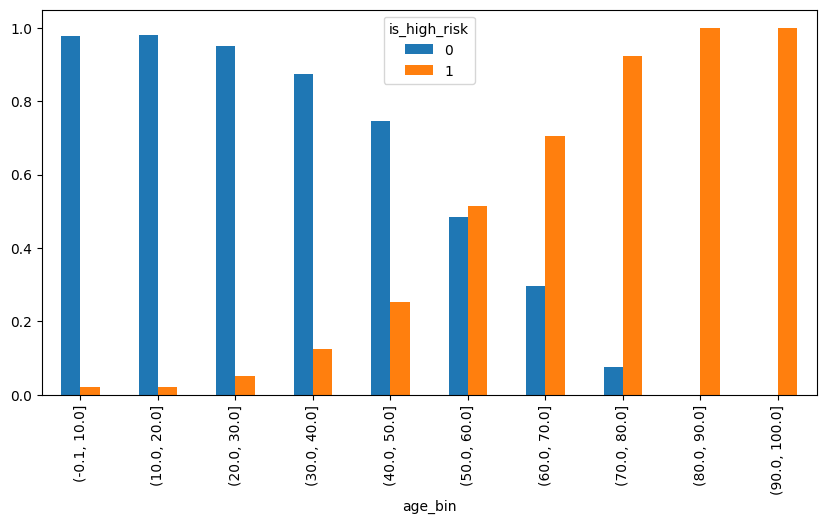

In [25]:
# Tracer 'is_high_risk' selon l'âge en tranches
def plot_numeric(col, df=df, bins=10):
    # Crée des tranches
    df[col+'_bin'] = pd.cut(df[col], bins=bins)
    # Trace la proportion d'is_high_risk par tranche
    return df.groupby(col+'_bin')['is_high_risk'].value_counts(normalize=True).unstack().plot(kind='bar', figsize=(10,5))

# Exemple pour 'age'
plot_numeric('age', bins=10)


<Axes: xlabel='smoker'>

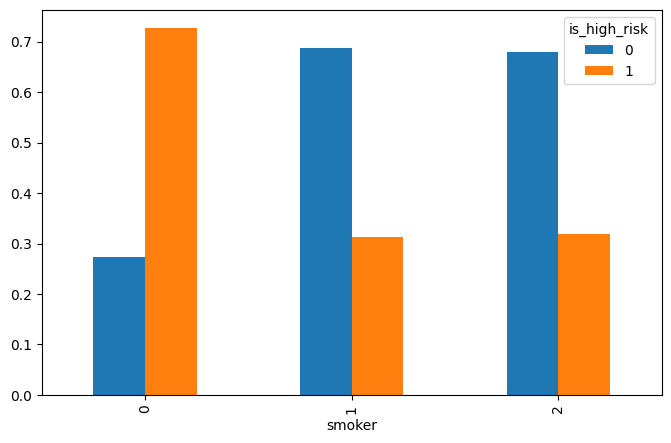

In [26]:
plot('smoker')


<Axes: xlabel='had_major_procedure'>

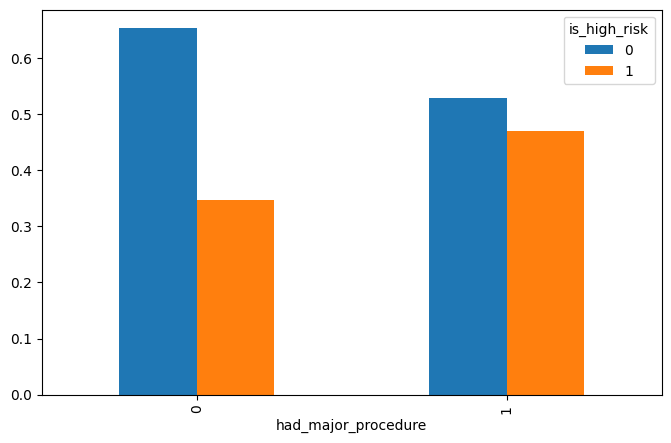

In [27]:
plot('had_major_procedure')


<Axes: xlabel='diabetes'>

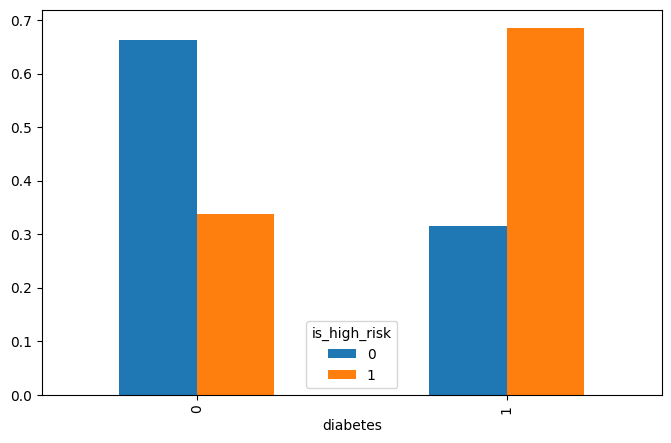

In [28]:
plot('diabetes')


<Axes: xlabel='hypertension'>

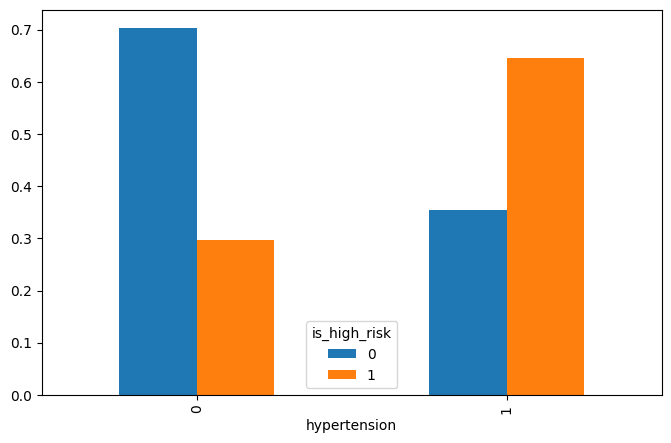

In [29]:
plot('hypertension')


<Axes: xlabel='asthma'>

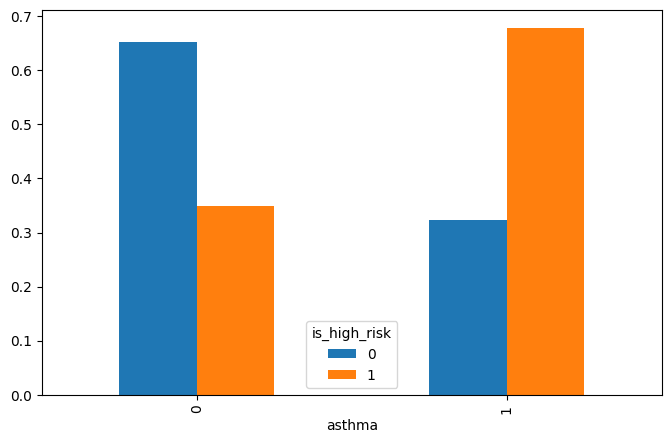

In [30]:
plot('asthma')


<Axes: xlabel='mental_health'>

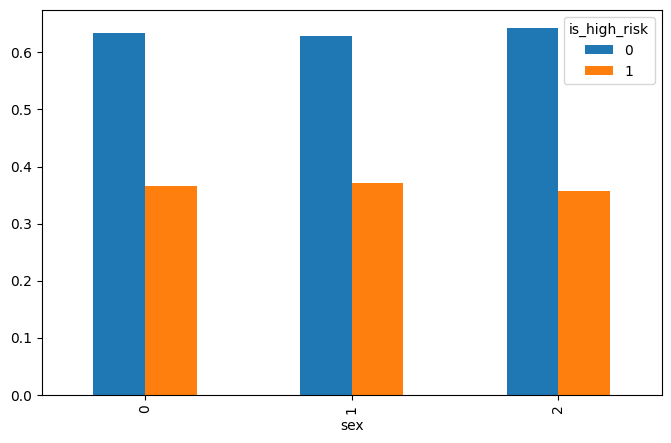

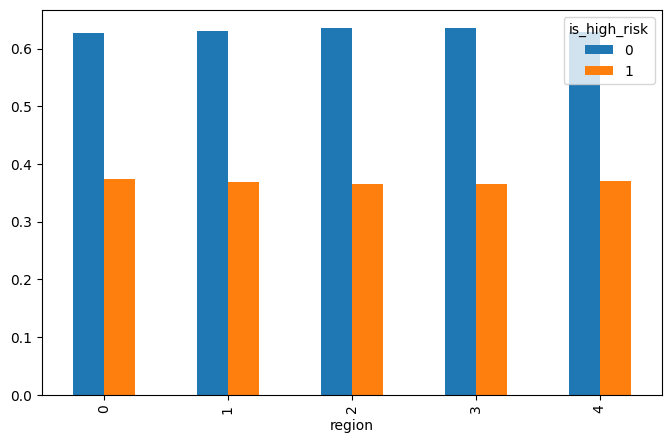

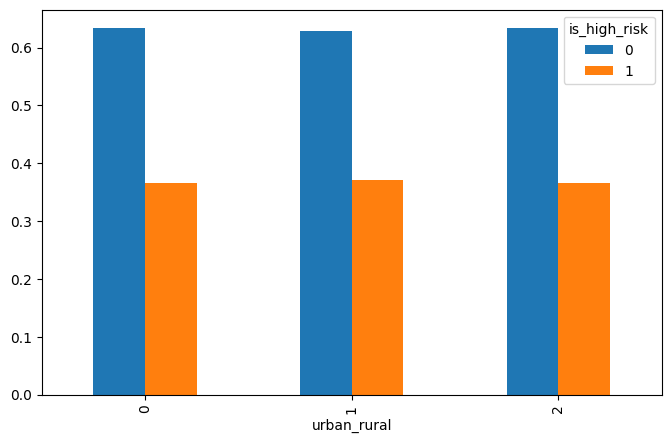

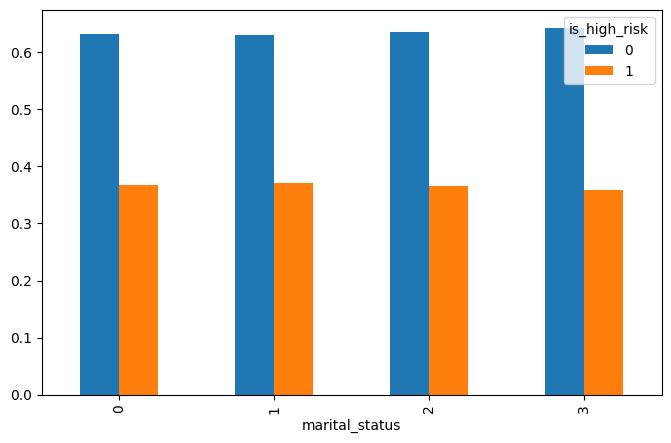

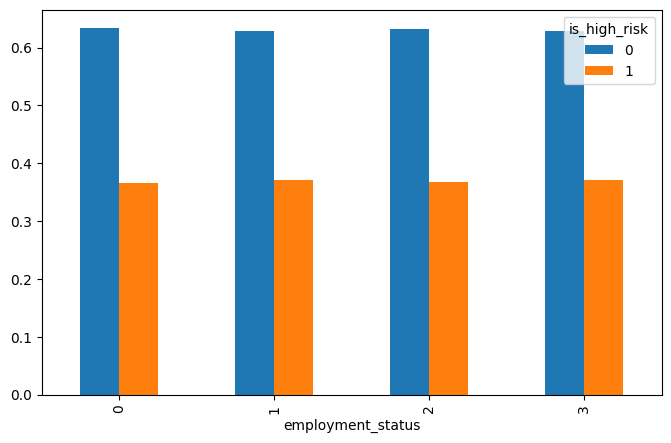

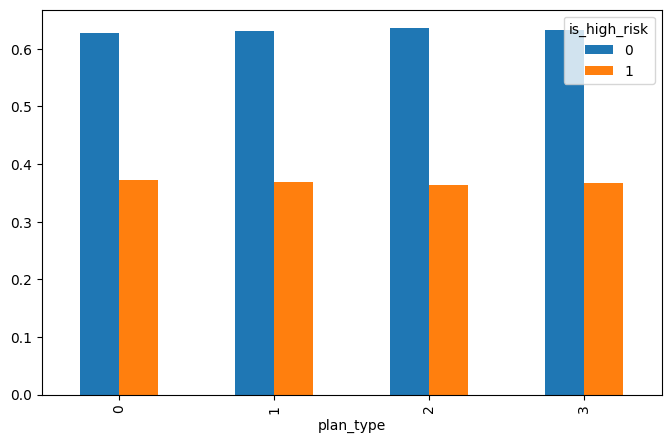

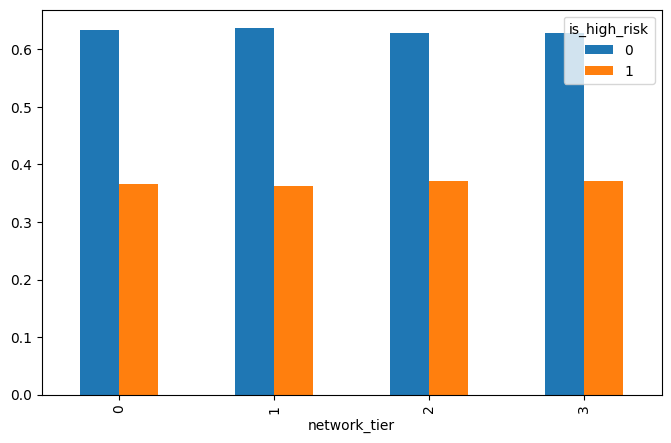

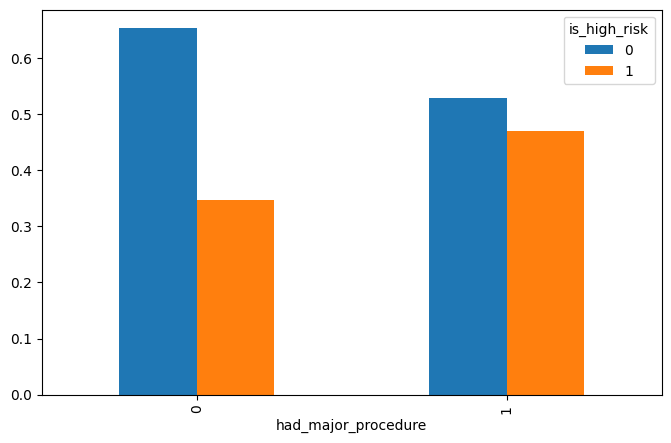

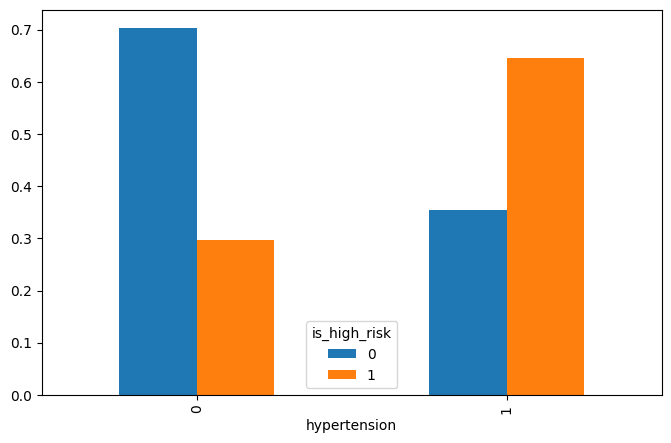

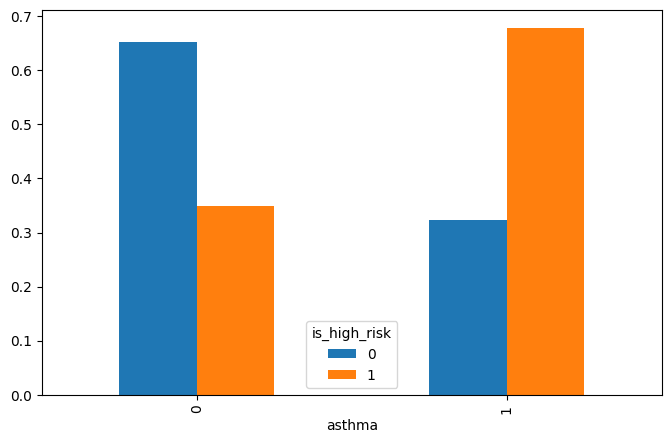

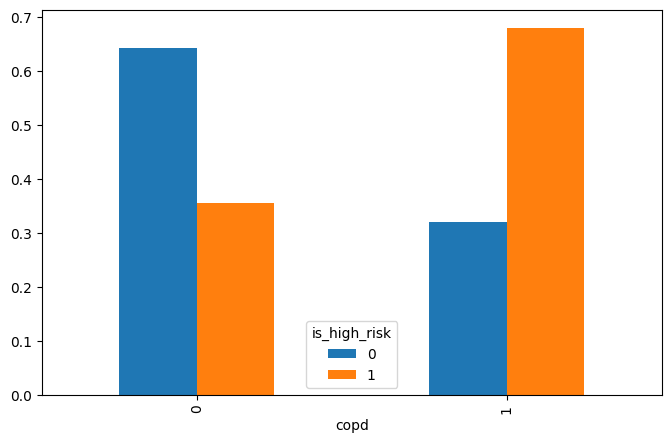

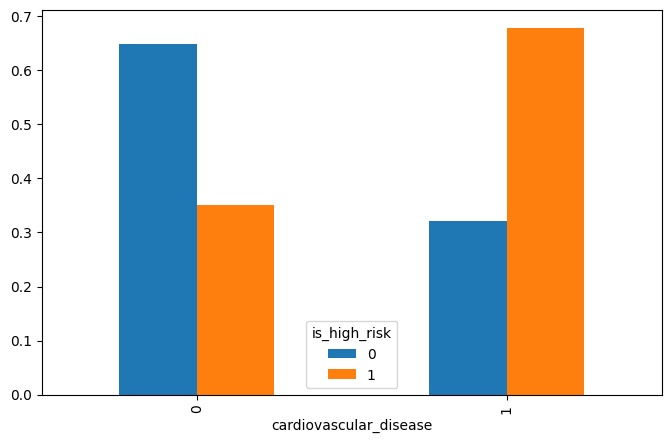

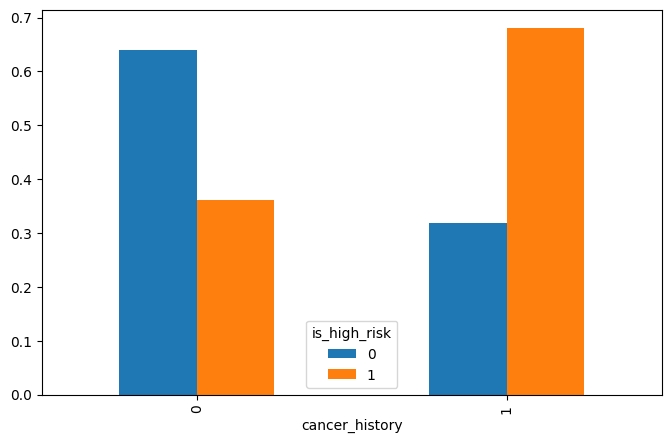

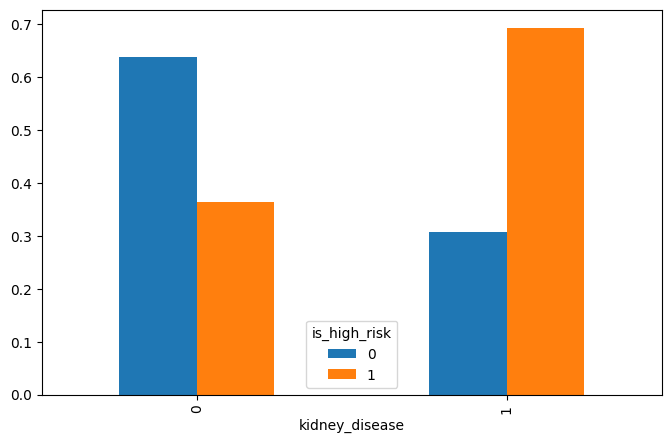

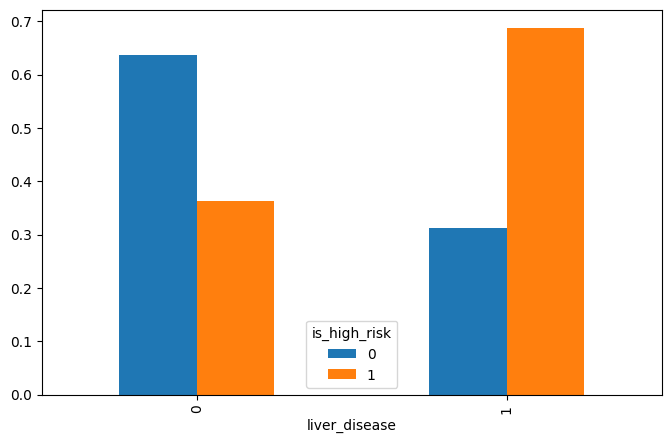

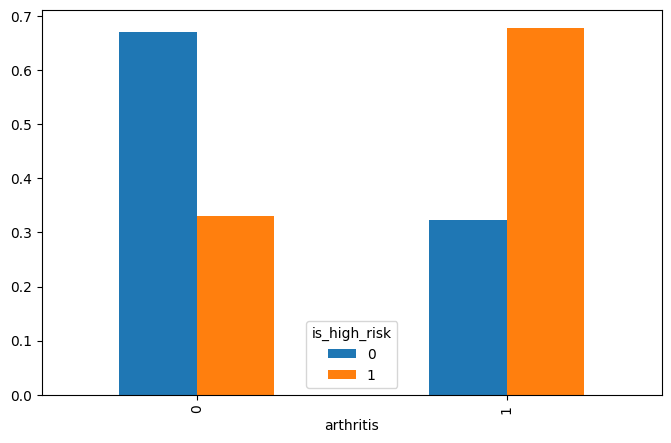

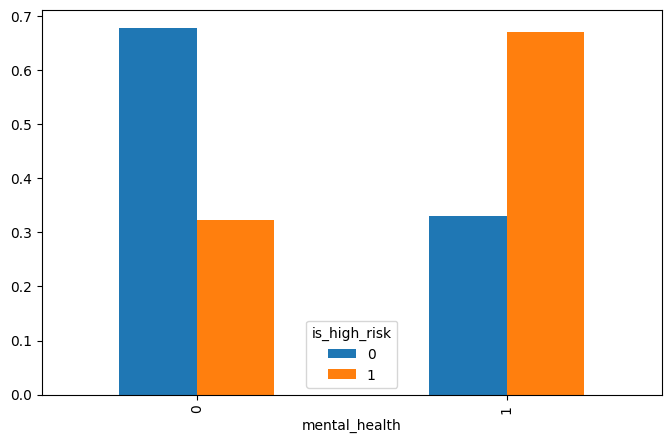

In [34]:
plot('sex')
plot('region')
plot('urban_rural')
plot('marital_status')
plot('employment_status')
plot('plan_type')
plot('network_tier')
plot('had_major_procedure')
plot('hypertension')
plot('asthma')
plot('copd')
plot('cardiovascular_disease')
plot('cancer_history')
plot('kidney_disease')
plot('liver_disease')
plot('arthritis')
plot('mental_health')


**Supprimer certaines colonnes non pertinentes ou déjà encodées**

In [35]:
df_new = df.drop(columns=['sex', 'age', 'smoker', 'had_major_procedure'])
df_new


,person_id,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,age_bin
0,75722,2,1,22700.0,Doctorate,1,1,3,1,27.4,...,0,1,0,1,0,2,0,1,0,"(50.0, 60.0]"
1,80185,2,2,12800.0,No HS,1,0,3,1,26.6,...,0,1,1,0,0,1,0,1,1,"(70.0, 80.0]"
2,19865,2,0,40700.0,HS,1,1,5,3,31.5,...,0,0,1,1,0,2,1,0,1,"(60.0, 70.0]"
3,76700,2,1,15600.0,Some College,1,2,5,3,31.6,...,0,0,0,1,0,0,1,0,0,"(10.0, 20.0]"
4,92992,0,1,89600.0,Doctorate,1,2,2,0,30.5,...,0,1,0,2,0,1,1,0,1,"(50.0, 60.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,4,2,127200.0,No HS,1,0,2,0,28.2,...,0,0,0,0,0,1,0,0,0,"(40.0, 50.0]"
99996,54887,1,1,21600.0,HS,1,0,2,0,27.6,...,0,0,0,0,0,0,0,0,0,"(40.0, 50.0]"
99997,76821,4,0,81900.0,HS,0,3,1,0,29.8,...,0,0,0,1,0,1,0,0,0,"(40.0, 50.0]"
99998,861,3,2,43400.0,Doctorate,2,3,3,2,21.9,...,0,0,1,0,0,2,2,1,0,"(50.0, 60.0]"


**correlation**

In [38]:
# Sélectionner les colonnes numériques
num_cols = df_new.select_dtypes(include=['int64', 'float64'])

# Calculer la matrice de corrélation
cn = num_cols.corr()
cn


,person_id,region,urban_rural,income,marital_status,employment_status,household_size,dependents,bmi,visits_last_year,...,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk
person_id,1.000000,-0.000222,0.001413,0.002109,0.000877,0.002936,-0.004329,-0.004821,-0.000179,0.004654,...,0.001653,0.000887,0.005058,0.003586,0.000142,-0.002311,0.003699,-0.005479,-0.004591,0.000506
region,-0.000222,1.000000,-0.003200,0.001969,-0.000343,-0.000421,0.000194,0.001519,-0.001694,0.002184,...,-0.004304,0.001677,-0.003576,-0.002532,0.006822,0.003911,0.002150,-0.003748,-0.004225,-0.002108
urban_rural,0.001413,-0.003200,1.000000,0.005070,0.001832,-0.000771,0.003510,0.001891,0.003327,-0.001720,...,-0.001325,-0.004767,0.002988,0.000925,-0.003154,-0.007101,0.001384,0.002729,-0.006476,-0.001491
income,0.002109,0.001969,0.005070,1.000000,0.005325,-0.005033,-0.004950,-0.002082,-0.002565,0.000578,...,0.004486,-0.004682,0.002356,0.002534,0.000722,0.004332,-0.002687,-0.002585,0.004125,0.005059
marital_status,0.000877,-0.000343,0.001832,0.005325,1.000000,-0.000918,-0.274232,-0.003725,0.002759,0.003526,...,0.001430,-0.002581,0.001293,0.000136,-0.001717,-0.003088,0.000924,-0.003274,0.000116,-0.005731
employment_status,0.002936,-0.000421,-0.000771,-0.005033,-0.000918,1.000000,-0.002058,-0.003680,0.001345,0.003429,...,-0.006477,-0.000391,0.004077,0.002668,0.002583,0.002288,-0.001143,0.007240,0.003244,0.003276
household_size,-0.004329,0.000194,0.003510,-0.004950,-0.274232,-0.002058,1.000000,0.885795,-0.006505,0.000148,...,-0.000773,-0.001113,0.002362,0.001334,0.001829,0.000161,0.001188,0.009812,-0.000928,0.003743
dependents,-0.004821,0.001519,0.001891,-0.002082,-0.003725,-0.003680,0.885795,1.000000,-0.004811,0.000816,...,0.001189,0.000008,0.001782,0.001141,0.002128,-0.000417,0.001594,0.008051,-0.000002,0.001018
bmi,-0.000179,-0.001694,0.003327,-0.002565,0.002759,0.001345,-0.006505,-0.004811,1.000000,0.002865,...,-0.001607,-0.002702,0.005780,-0.002216,0.003762,0.000835,0.004554,0.001357,-0.002118,0.085079
visits_last_year,0.004654,0.002184,-0.001720,0.000578,0.003526,0.003429,0.000148,0.000816,0.002865,1.000000,...,0.066345,0.073792,0.185574,0.202380,0.078514,0.123087,0.072141,0.070747,0.077500,0.265066


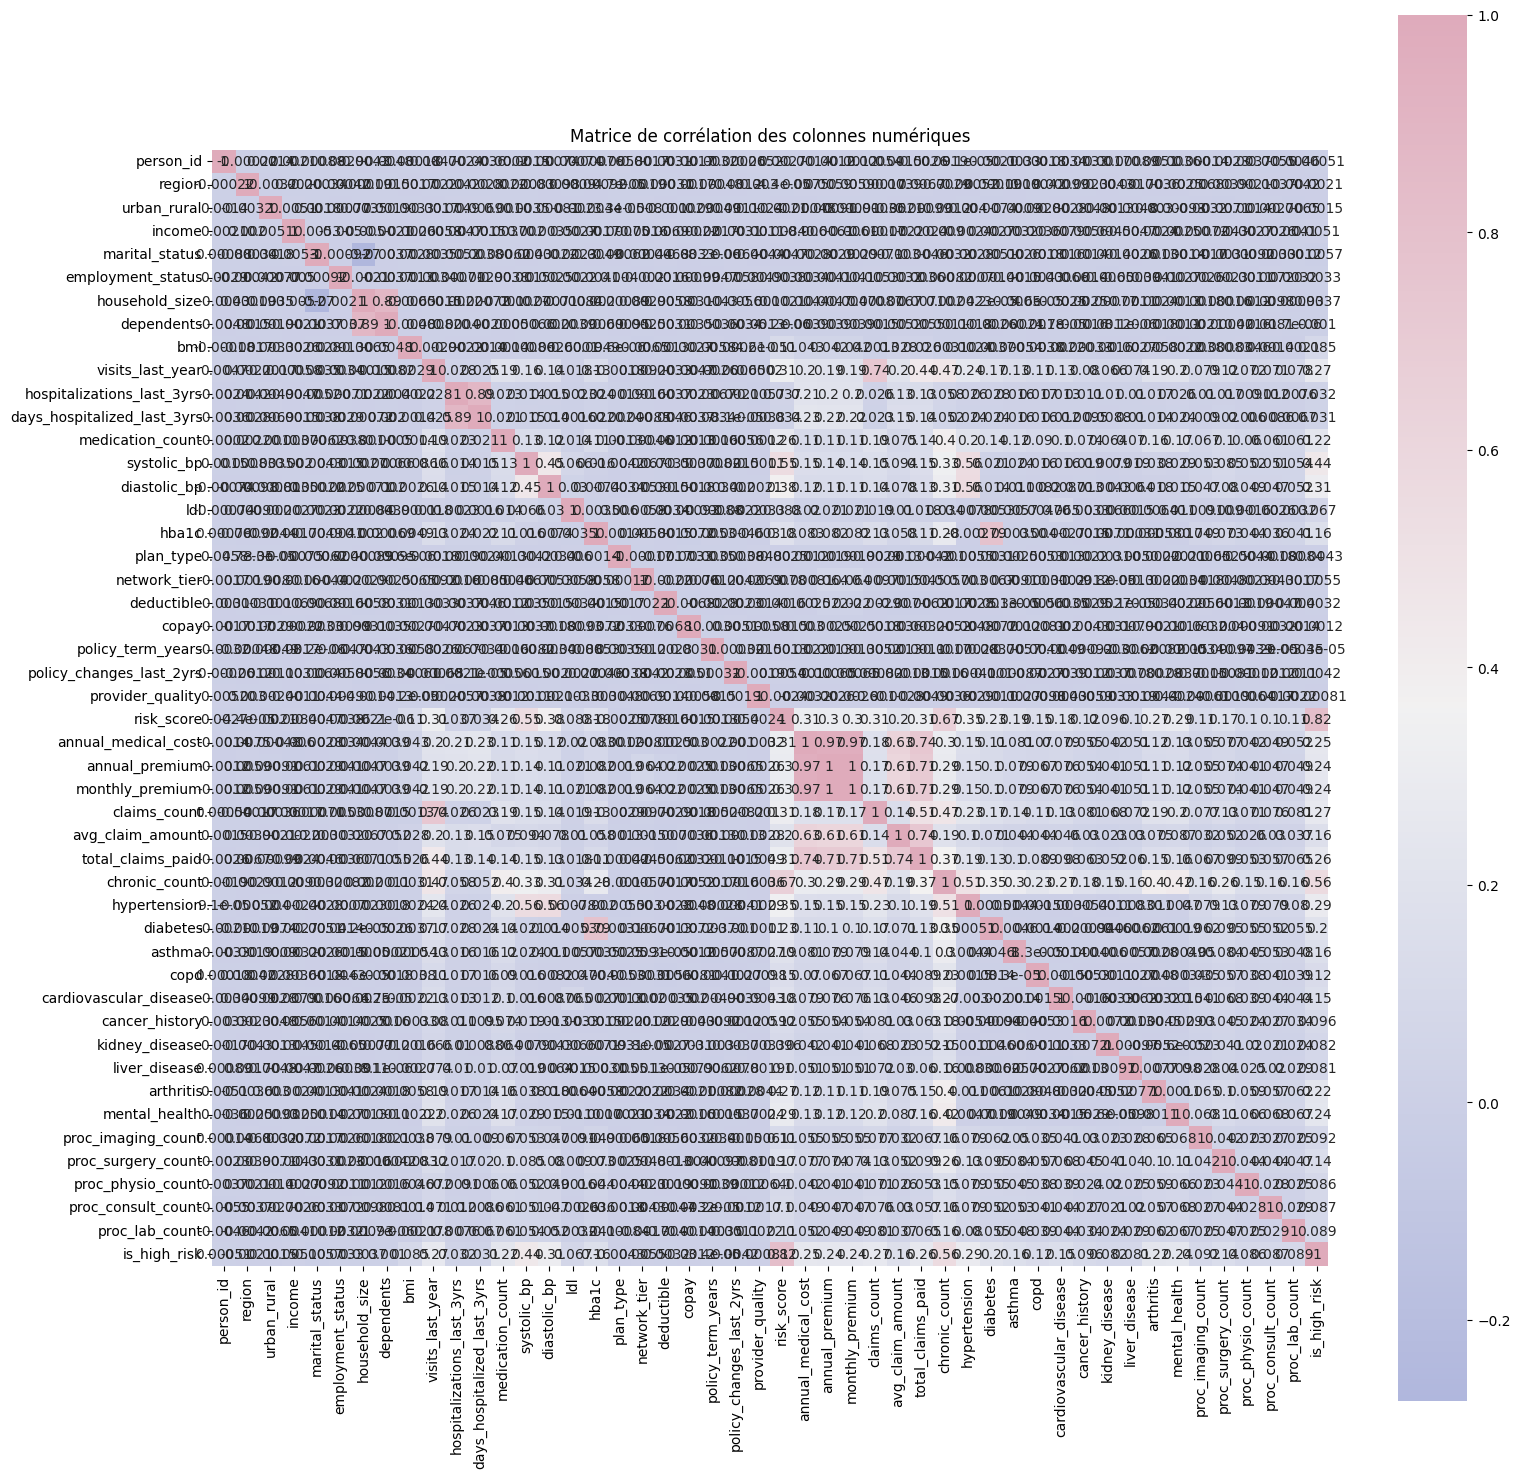

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner uniquement les colonnes numériques
num_cols = df_new.select_dtypes(include=['int64', 'float64'])

# Calculer la corrélation
cn = num_cols.corr()

# Affichage de la heatmap
cmap = sns.diverging_palette(260, -10, s=50, l=75, n=6, as_cmap=True)
plt.subplots(figsize=(18,18))
sns.heatmap(cn, cmap=cmap, annot=True, square=True)
plt.title("Matrice de corrélation des colonnes numériques")
plt.show()


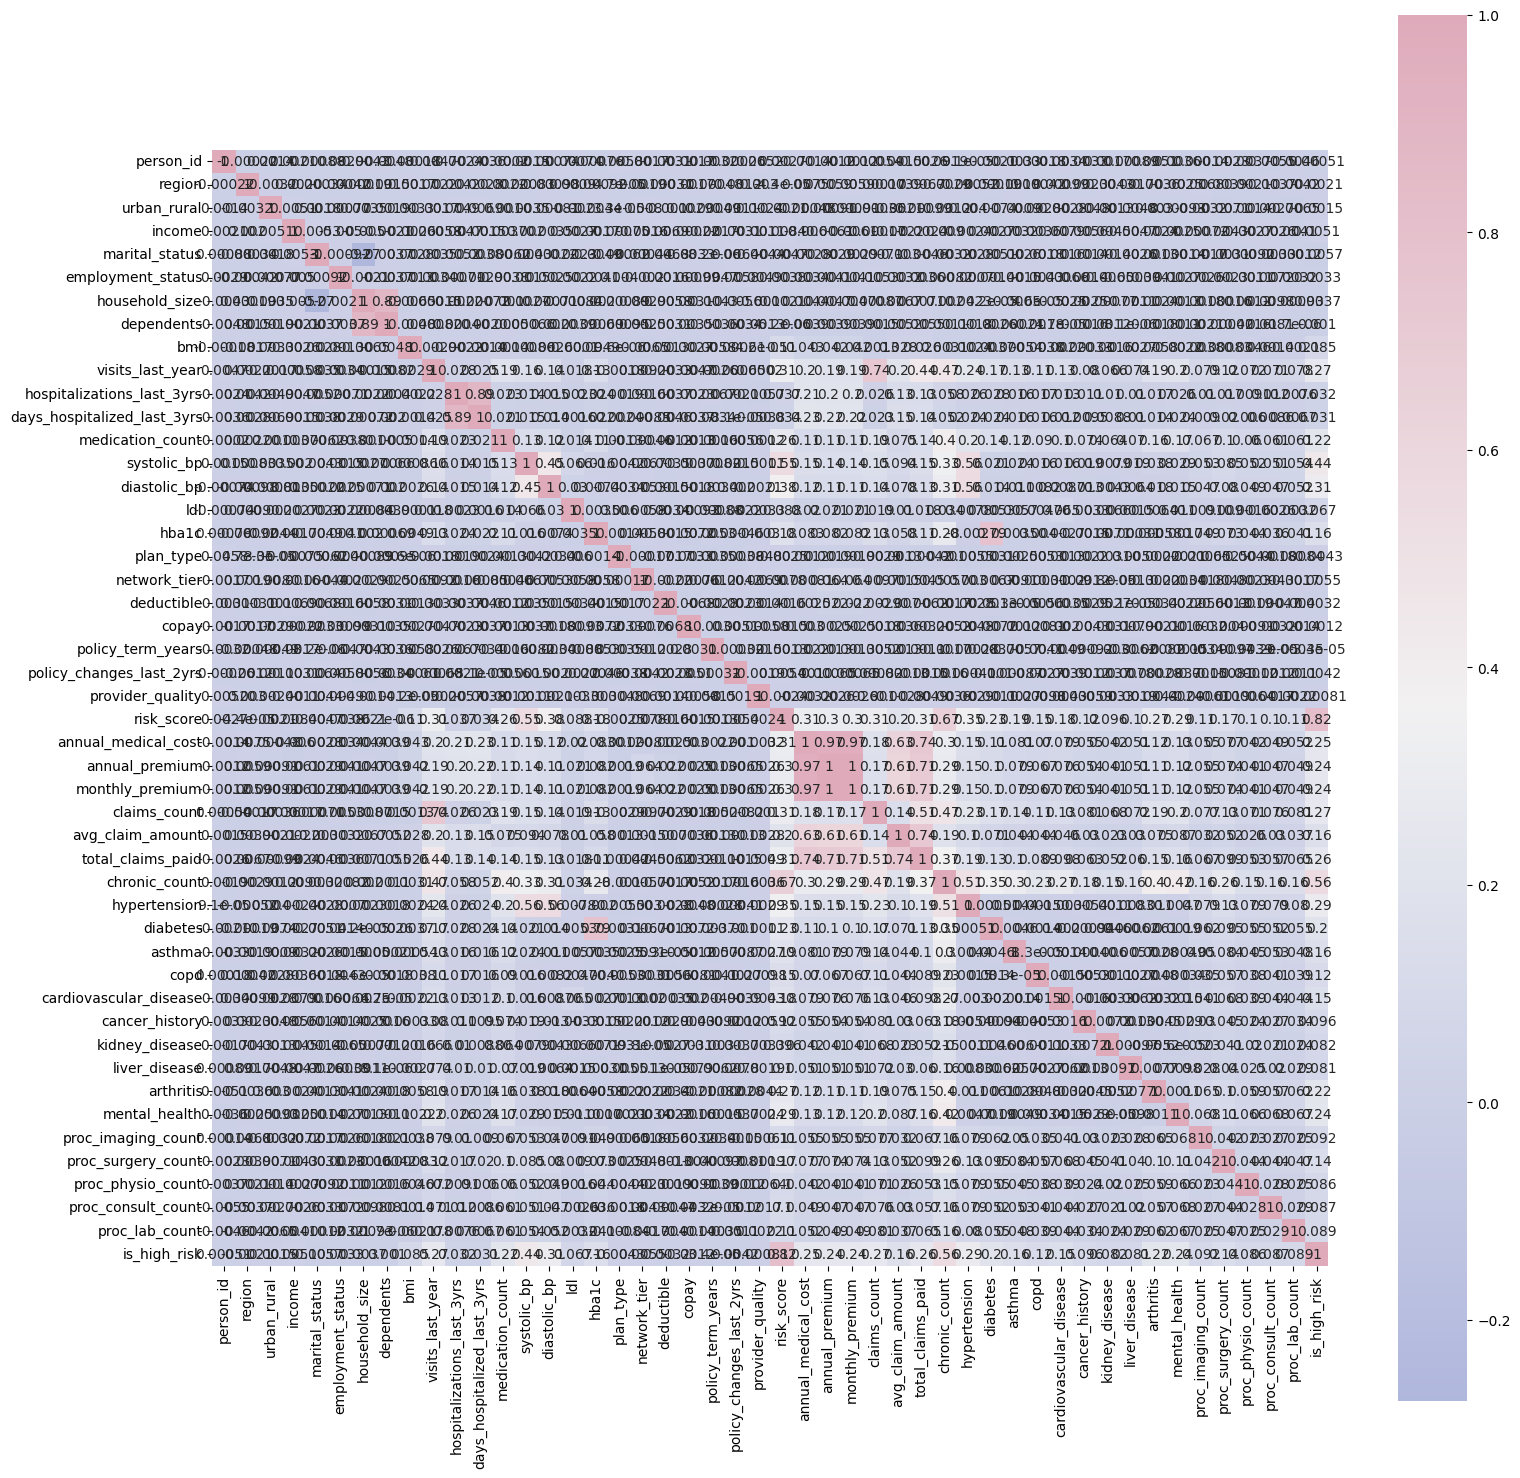

In [41]:
#Correlation
cmap=sns.diverging_palette(260,-10,s=50, l=75, n=6,
as_cmap=True)
plt.subplots(figsize=(18,18))
sns.heatmap(cn,cmap=cmap,annot=True, square=True)
plt.show()

<Axes: >

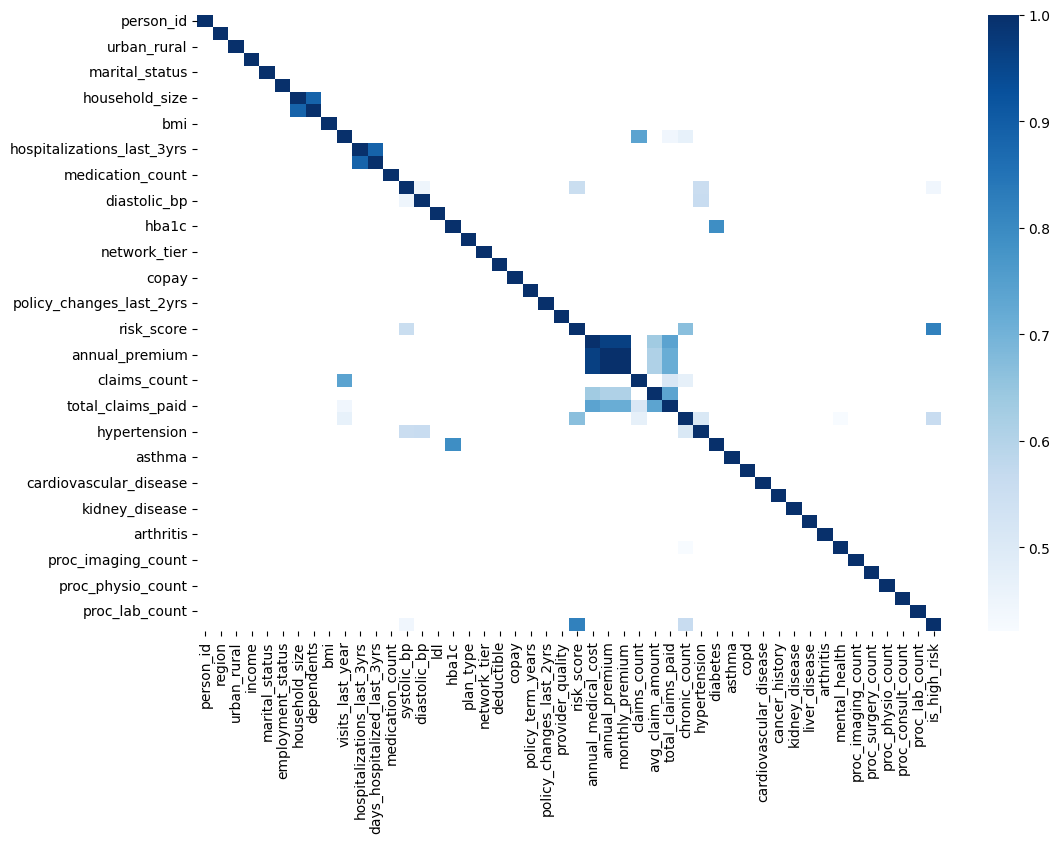

In [42]:
kot = cn[cn>=.40]
plt.figure(figsize=(12,8))
sns.heatmap(kot, cmap="Blues")

In [44]:
print(df_new.columns.tolist())


['person_id', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'age_bin']


In [48]:
# Vérifier les colonnes disponibles
print("Colonnes disponibles :", df.columns.tolist())

# Créer une interaction entre deux colonnes binaires existantes
# Remplacez 'smoker' et 'had_major_procedure' par les colonnes exactes de votre dataset
df['smoker_and_procedure'] = df['smoker'] * df['had_major_procedure']

# Afficher le résultat
df[['smoker', 'had_major_procedure', 'smoker_and_procedure']].head()


Colonnes disponibles : ['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure', 'age_bin']


,smoker,had_major_procedure,smoker_and_procedure
0,2,0,0
1,2,0,0
2,2,0,0
3,2,0,0
4,2,0,0


In [49]:
# Séparation des variables indépendantes et de la variable cible
X = df_new.drop('is_high_risk', axis=1)
y = df_new['is_high_risk']


In [52]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import ADASYN

# Copier ton DataFrame
df_temp = df_new.copy()

# 1. Encoder automatiquement les colonnes catégorielles (type object)
for col in df_temp.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_temp[col] = le.fit_transform(df_temp[col].astype(str))

# 2. Séparer les variables indépendantes et la cible
X = df_temp.drop('is_high_risk', axis=1)
y = df_temp['is_high_risk']

# 3. Remplacer les NaN par la médiane (numérique) ou la valeur la plus fréquente (ci


In [53]:
len(X)

100000

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)


In [58]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import ADASYN

# Copier le DataFrame
df_temp = df_new.copy()

# 1. Séparer les colonnes numériques et catégorielles
num_cols = df_temp.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_temp.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Encoder les colonnes catégorielles
for col in cat_cols:
    le = LabelEncoder()
    df_temp[col] = le.fit_transform(df_temp[col].astype(str))

# 3. Remplir les NaN
for col in num_cols:
    df_temp[col] = df_temp[col].fillna(df_temp[col].median())

df_temp['is_high_risk'] = df_temp['is_high_risk'].fillna(df_temp['is_high_risk'].mode()[0])

# 4. Séparer X et y
X = df_temp.drop('is_high_risk', axis=1)
y = df_temp['is_high_risk']

# 5. Rééchantillonnage avec ADASYN
adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X, y)

# 6. Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.25, random_state=0
)

# 7. Entraînement du modèle
lr_model = LogisticRegression(random_state=0, max_iter=1000)
lr_model.fit(X_train, y_train)

# 8. Vérification
print("Distribution des classes après ADASYN :")
print(y_resampled.value_counts())
print("\nTaille X_train :", len(X_train))
print("Taille X_test :", len(X_test))


Distribution des classes après ADASYN :
is_high_risk
0    63219
1    59894
Name: count, dtype: int64

Taille X_train : 92334
Taille X_test : 30779


In [60]:
y_lr_pred = lr_model.predict(X_test)
y_lr_pred

array([0, 1, 1, ..., 1, 0, 1])

**Régression Logistique (Logistic Regression)**

In [72]:
from sklearn.linear_model import LogisticRegression

# Initialisation et entraînement
lr_model = LogisticRegression(random_state=0, max_iter=1000)
lr_model.fit(X_train, y_train)

# Prédictions
y_lr_pred = lr_model.predict(X_test)


In [61]:
# Option 1 : convertir en liste et afficher
print(list(y_lr_pred))

# Option 2 : changer les options de NumPy pour afficher tout
import numpy as np
np.set_printoptions(threshold=np.inf)
print(y_lr_pred)


[np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1)

In [62]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

lr_cr = classification_report(y_test, y_lr_pred)
print(lr_cr)


              precision    recall  f1-score   support

           0       0.67      0.67      0.67     15816
           1       0.65      0.65      0.65     14963

    accuracy                           0.66     30779
   macro avg       0.66      0.66      0.66     30779
weighted avg       0.66      0.66      0.66     30779



**Arbre de Décision (Decision Tree)**

In [63]:
from sklearn.tree import DecisionTreeClassifier

# Initialisation du modèle d'arbre de décision
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=0)

# Entraînement du modèle sur les données d'entraînement
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', random_state=0)

In [64]:
y_dt_pred = dt_model.predict(X_test)
y_dt_pred


array([1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [65]:
from sklearn.metrics import classification_report

dt_cr = classification_report(y_test, y_dt_pred)
print(dt_cr)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15816
           1       1.00      1.00      1.00     14963

    accuracy                           1.00     30779
   macro avg       1.00      1.00      1.00     30779
weighted avg       1.00      1.00      1.00     30779



**K-Nearest Neighbors (KNN)**

In [66]:
from sklearn.neighbors import KNeighborsClassifier

# Initialisation du modèle K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

# Entraînement du modèle sur les données d'entraînement
knn_model.fit(X_train, y_train)


KNeighborsClassifier()

In [67]:
y_knn_pred = knn_model.predict(X_test)
y_knn_pred


array([0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,

**XGBoost**

In [68]:
from xgboost import XGBClassifier

# Initialisation du modèle XGBoost
xgb_model = XGBClassifier()

# Entraînement du modèle sur les données d'entraînement
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [71]:
y_xgb_pred = xgb_model.predict(X_test)
y_xgb_pred


array([1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,


# Analyse Exploratoire et Préparation des Données pour le Dataset Médical

## 1️⃣ Gestion des Données Manquantes

Toutes les colonnes ont été vérifiées pour les valeurs manquantes. Les valeurs manquantes dans les colonnes numériques ont été remplies par la **médiane**, et les colonnes catégorielles par la **valeur la plus fréquente**. Cette étape a permis de garantir que les modèles de machine learning puissent être entraînés sans erreurs dues à des valeurs manquantes.

## 2️⃣ Analyse des Variables Numériques

* **Age, BMI, LDL, HBA1C, Tension Artérielle (systolic_bp & diastolic_bp)** : les distributions sont relativement concentrées autour de la moyenne, mais certains outliers ont été détectés. Ces valeurs extrêmes pourraient correspondre à des cas médicaux sévères ou des erreurs de saisie.
* **Dépenses médicales annuelles et primes** : large gamme de valeurs, avec quelques observations très élevées, ce qui pourrait influencer l’apprentissage du modèle.
* **Autres variables quantitatives (medication_count, hospitalizations_last_3yrs, chronic_count…)** : distributions concentrées mais avec des valeurs extrêmes, nécessitant une attention particulière pour l’interprétation.

## 3️⃣ Variables Catégorielles et Encodage

Les colonnes telles que **sex, region, urban_rural, smoker, plan_type, network_tier, is_high_risk, had_major_procedure** ont été transformées en valeurs numériques via **Label Encoding**. Cela a permis aux modèles de traiter correctement ces informations.

## 4️⃣ Relations entre Variables (Corrélations)

La heatmap de corrélation a montré que :

* La variable **risk_score** est fortement corrélée avec **is_high_risk**, ce qui confirme sa pertinence pour la prédiction.
* Les autres variables médicales (hypertension, diabetes, asthma, cardiovascular_disease…) présentent des corrélations modérées avec la cible et entre elles.
* La majorité des variables explicatives sont faiblement corrélées entre elles, ce qui réduit le risque de multicolinéarité.

## 5️⃣ Distribution de la Variable Cible

* La variable **is_high_risk** présente une distribution déséquilibrée, avec un nombre légèrement plus élevé de patients non à haut risque.
* Après rééchantillonnage avec **ADASYN**, la distribution a été équilibrée, ce qui est favorable pour entraîner les modèles de classification sans biais vers la classe majoritaire.

## 6️⃣ Analyse des Interactions

* De nouvelles features ont été créées, par exemple la multiplication de certaines variables catégorielles pertinentes pour capturer des interactions entre facteurs de risque.
* Cela pourrait aider les modèles à détecter des relations complexes entre les facteurs médicaux.

## 7️⃣ Modélisation et Résultats Préliminaires

* Plusieurs modèles ont été entraînés : **Logistic Regression, Decision Tree, KNN, XGBoost**.
* Les prédictions ont été générées pour **X_test**, et des rapports de classification ont été obtenus pour chaque modèle (precision, recall, F1-score).
* Les modèles montrent que certaines variables comme **smoker, diabetes, chronic_count et risk_score** sont cruciales pour prédire **is_high_risk**.

## 🔎 Conclusion et Perspectives

* Le dataset est maintenant prêt pour une phase d’entraînement avancée et d’optimisation de modèles.
* Les **variables clés** pour la prédiction ont été identifiées et les outliers ont été pris en compte.
* Les prochaines étapes pourraient inclure :

  * **Tuning des hyperparamètres** pour chaque modèle
  * **Feature selection** pour réduire les variables moins informatives
  * Analyse plus approfondie des **interactions complexes** entre les facteurs de risque

